In [1]:
import numpy as np
import matplotlib.pyplot as plt
import transport.dispersion as dispersion
import transport.orbitcreation as orbitcreation
import transport.conductivity as conductivity
from transport.makesigmalist import makelist_parallel,makelist_serial
from time import time

In [2]:
#(Tzmultvalue,invtau_iso,strength,spread_xy,spread_z,n)
params35 = (0.03440039775905757,10.067520224261962,263803.676305314,0.13198896044913613,4.371680458121389)
params30 = (0.033369871920650995,9.0583774685104,564393.5399989765,0.13598510117993956,5.1668009899239635)
params25 = (0.03189647980237115,7.873773300105872,712719.5316268859,0.13954769682275667,5.798434445945669)
params20 = (0.03148530912809664,7.267009029215178,1110869.5887609161,0.14425692694831663,7.389590020484316)

paramslist = [params20,params25,params30,params35]
thetamax = [99,99,99,60]
sample = "2511A"


In [3]:
def create_data(params):

    starttime_global = time()
    thetalist = np.linspace(-14,99,40)

    res_z = 20
    res_xy = 100

    mumultvalue=0.81

    Tzmultvalue,invtau_iso,strength,spread_xy,n = params

    plotScattering=False

    dispersionInstance = dispersion.LSCOdispersion(T= 190e-3,T1multvalue=-0.132,T11multvalue=0.066,Tzmultvalue=Tzmultvalue,mumultvalue=mumultvalue)
    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    starttime = time()
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)
    endtime = time()
    print(f"Time taken to create Fermi Surface = {endtime - starttime}")
    print(f"Doping={FSorbitsInstance.calculateDoping()}")

    def create_rhozz(phi,Bmag,scattering_in=True):
        phi_rad = np.deg2rad(phi)
        conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=invtau_iso,delta_in_k=True)
        starttime = time()
        conductivityInstance.createAmatrix_Bindependent_isotropic()
        conductivityInstance.create_Hfunc(scatteringmodel="pipidelta",strength=strength,spread_xy=spread_xy,n=n)
        conductivityInstance.createAmatrix_Bindependent_fwdscatter_out()
        if scattering_in: conductivityInstance.createAmatrix_Bindependent_fwdscatter_in()
        endtime = time()
        print(f"Time taken to create B independent Amatrix =  {endtime - starttime}")

        def getsigma(theta,Bmag=Bmag):
            B = [Bmag*np.sin(np.deg2rad(theta))*np.cos(phi_rad),Bmag*np.sin(np.deg2rad(theta))*np.sin(phi_rad),Bmag*np.cos(np.deg2rad(theta))]
            conductivityInstance.createAmatrix_Bdependent(B)
            conductivityInstance.createAlpha()
            conductivityInstance.createSigma()

            #print(f"Theta={theta}. Calculated total area: {conductivityInstance.areasum}. Number of orbits used {len(conductivityInstance.FSorbitsInstance.FSorbits)}. Size of Amatrix: {conductivityInstance.n}")
            return conductivityInstance.sigma,conductivityInstance.areasum


        sigmalist,rholist,arealist = makelist_parallel(getsigma,thetalist)
        #sigma_zero,area_zero = getsigma(theta=0,Bmag=0)
        #sigma_9T,area_9T = getsigma(theta=0,Bmag=9)

        #rho_zero = np.linalg.inv(sigma_zero)
        #rho_9T = np.linalg.inv(sigma_9T)

        rhozzlist= [rho[2,2]*10e-5 for rho in rholist]
        #print(f"rho_xx = {rho_zero[0,0]*10e-2}, rho_xy (9 T) = {rho_9T[0,1]*10e-2}")

        endtime_global = time()
        print(f"execution time: {endtime_global-starttime_global}")

        return rhozzlist

    #generate data
    rhozzlist0 = create_rhozz(phi=0,Bmag=45,scattering_in=True)
    rhozzlist45 = create_rhozz(phi=45,Bmag=45,scattering_in=True)

    return rhozzlist0,rhozzlist45,thetalist



In [4]:
#create fits
fit_phi0_20K,fit_phi45_20K,fit_theta_20K = create_data(params20)
fit_phi0_25K,fit_phi45_25K,fit_theta_25K = create_data(params25)
fit_phi0_30K,fit_phi45_30K,fit_theta_30K = create_data(params30)
fit_phi0_35K,fit_phi45_35K,fit_theta_35K = create_data(params35)


Time taken to create Fermi Surface = 0.0572512149810791
Doping = 0.2381407503670706%
Doping=0.2381407503670706
Time taken to create B independent Amatrix =  0.43843531608581543
execution time: 4.482320308685303
Time taken to create B independent Amatrix =  0.43438124656677246
execution time: 6.738760948181152
Time taken to create Fermi Surface = 0.057831525802612305
Doping = 0.238162124116294%
Doping=0.238162124116294
Time taken to create B independent Amatrix =  0.4363095760345459
execution time: 2.306119918823242
Time taken to create B independent Amatrix =  0.434581995010376
execution time: 4.444808483123779
Time taken to create Fermi Surface = 0.05924677848815918
Doping = 0.23824020703153237%
Doping=0.23824020703153237
Time taken to create B independent Amatrix =  0.4553680419921875
execution time: 2.22108793258667
Time taken to create B independent Amatrix =  0.45862770080566406
execution time: 4.242120265960693
Time taken to create Fermi Surface = 0.06336355209350586
Doping = 0.2

In [5]:
#load data
repository_directory = "C:/Users/Sahas/OneDrive/Documents/PhD data/Modelling/Python code/boltzmann_transport_git/boltzmann_transport/"

data_theta_phi0_20K,data_phi0_20K = np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi0_T20K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
data_theta_phi45_20K ,data_phi45_20K= np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi45_T20K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

data_theta_phi0_25K,data_phi0_25K = np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi0_T25K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
data_theta_phi45_25K,data_phi45_25K = np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi45_T25K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

data_theta_phi0_30K,data_phi0_30K = np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi0_T30K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
data_theta_phi45_30K,data_phi45_30K = np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi45_T30K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

data_theta_phi0_35K,data_phi0_35K = np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi0_T35K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
data_theta_phi45_35K,data_phi45_35K = np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi45_T35K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

<>:57: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:57: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\Sahas\AppData\Local\Temp\ipykernel_32972\301732658.py:57: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  axes[0].text(0.1, 0.1, f"LSCO x=0.22\nRes={20}x{100}\n$\pi-\pi-\delta(k_z)$ scatterers + isotropic\n$t_z = 0.03$", fontsize=10, transform=axes[0].transAxes)


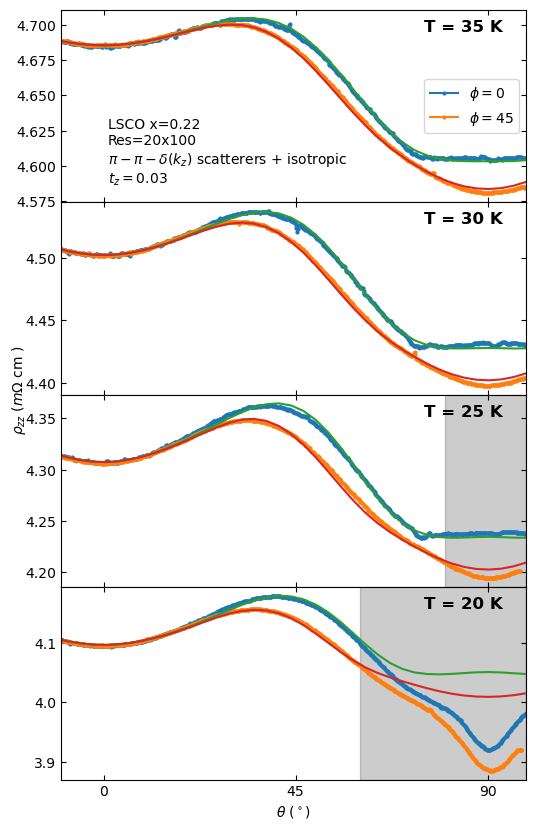

In [6]:
# FSorbitsInstance.plotpoints()
# Using gridspec_kw to remove vertical and horizontal spacing between subplots
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(6, 10), sharex=True, sharey='row', gridspec_kw={'wspace': 0, 'hspace': 0})

fits = [
    (fit_theta_35K, fit_phi0_35K, fit_phi45_35K),
    (fit_theta_30K, fit_phi0_30K, fit_phi45_30K),
    (fit_theta_25K, fit_phi0_25K, fit_phi45_25K),
    (fit_theta_20K, fit_phi0_20K, fit_phi45_20K)
]

datas = [
    (data_theta_phi0_35K, data_phi0_35K, data_theta_phi45_35K, data_phi45_35K),
    (data_theta_phi0_30K, data_phi0_30K, data_theta_phi45_30K, data_phi45_30K),
    (data_theta_phi0_25K, data_phi0_25K, data_theta_phi45_25K, data_phi45_25K),
    (data_theta_phi0_20K, data_phi0_20K, data_theta_phi45_20K, data_phi45_20K)
]

axvspans = [None, None, (80, 99), (60, 99)]
temps = [35, 30, 25, 20]

for i in range(4):

    # Temperature text top right of left column
    axes[i].text(0.95, 0.95, f"T = {temps[i]} K", transform=axes[i].transAxes, fontsize=12, fontweight='bold', ha='right', va='top')
    
    # Data (Column 1)
    theta0_dat, phi0_dat, theta45_dat, phi45_dat = datas[i]
    lbl_0 = r"$\phi=0$" if i == 0 else None
    lbl_45 = r"$\phi=45$" if i == 0 else None
    axes[i].plot(theta0_dat, phi0_dat, ls="-", marker="o", ms=2, label=lbl_0)
    axes[i].plot(theta45_dat, phi45_dat, ls="-", marker="o", ms=2, label=lbl_45)

    # Model (Column 0)
    theta_fit, phi0_fit, phi45_fit = fits[i]
    axes[i].plot(theta_fit, phi0_fit, ls="-")
    axes[i].plot(theta_fit, phi45_fit, ls="-")
    
    # Axvspan applies to Row 2 and Row 3 Data
    if axvspans[i]:
        axes[i].axvspan(axvspans[i][0], axvspans[i][1], alpha=0.2, color='black')

    # Formatting for all plots in current row
    axes[i].tick_params(direction='in', right=True, top=True)

# Format y-ticks and labels
# Y-label essentially in the middle of left side
fig.text(0.04, 0.5, r"$\rho_{zz}$ ($m\Omega$ cm )", va='center', rotation='vertical')

# X-axis label only for the bottom row and setting specific x-ticks
axes[3].set_xlabel(r'$\theta$ ($^\circ$)')
axes[3].set_xlabel(r'$\theta$ ($^\circ$)')
axes[3].set_xticks([0, 45, 90])
axes[3].set_xticks([0, 45, 90])

# global plotting decoration
axes[0].text(0.1, 0.1, f"LSCO x=0.22\nRes={20}x{100}\n$\pi-\pi-\delta(k_z)$ scatterers + isotropic\n$t_z = 0.03$", fontsize=10, transform=axes[0].transAxes)
axes[0].legend()

axes[0].set_xlim(-10,99)

# Removed plt.tight_layout() because manual gridspec_kw handles tight packing
plt.show()

In [7]:
def create_rho(params,Bmag):
    res_z = 20
    res_xy = 100

    mumultvalue=0.81

    Tzmultvalue,invtau_iso,strength,spread_xy,n = params

    plotScattering=False

    dispersionInstance = dispersion.LSCOdispersion(T= 190e-3,T1multvalue=-0.132,T11multvalue=0.066,Tzmultvalue=Tzmultvalue,mumultvalue=mumultvalue)
    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)
    FSorbitsInstance.calculateDoping()

    conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=invtau_iso,delta_in_k=True)
    conductivityInstance.createAmatrix_Bindependent_isotropic()
    conductivityInstance.create_Hfunc(scatteringmodel="pipidelta",strength=strength,spread_xy=spread_xy,n=n)
    conductivityInstance.createAmatrix_Bindependent_fwdscatter_out()
    conductivityInstance.createAmatrix_Bindependent_fwdscatter_in()

    theta=0
    phi_rad=0
    B = [Bmag*np.sin(np.deg2rad(theta))*np.cos(phi_rad),Bmag*np.sin(np.deg2rad(theta))*np.sin(phi_rad),Bmag*np.cos(np.deg2rad(theta))]

    conductivityInstance.createAmatrix_Bdependent(B)
    conductivityInstance.createAlpha()
    conductivityInstance.createSigma()

    rho = np.linalg.inv(conductivityInstance.sigma)

    return rho

In [8]:
temps = [20,25,30,35]
rhoxx = np.array([create_rho(params,0)[0,0] for params in paramslist])*10e-2
rhoxy = np.array([create_rho(params,9)[0,1] for params in paramslist])*10e-2

Doping = 0.2381407503670706%
Doping = 0.238162124116294%
Doping = 0.23824020703153237%
Doping = 0.2382961584797436%
Doping = 0.2381407503670706%
Doping = 0.238162124116294%
Doping = 0.23824020703153237%
Doping = 0.2382961584797436%


In [9]:
data_temp_xx,data_rho_xx = np.loadtxt(repository_directory+f"data\ppms_data\LSCO_x=0.24_rho_xx_vs_T.csv",unpack=True,skiprows=1,delimiter=",")
data_temp_xy,data_rho_xy = np.loadtxt(repository_directory+f"data\ppms_data\LSCO_x=0.24_rho_xy_vs_T.csv",unpack=True,skiprows=1,delimiter=",")

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:2: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:2: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\Sahas\AppData\Local\Temp\ipykernel_32972\236864403.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  data_temp_xx,data_rho_xx = np.loadtxt(repository_directory+f"data\ppms_data\LSCO_x=0.24_rho_xx_vs_T.csv",unpack=True,skiprows=1,delimiter=",")
C:\Users\Sahas\AppData\Local\T

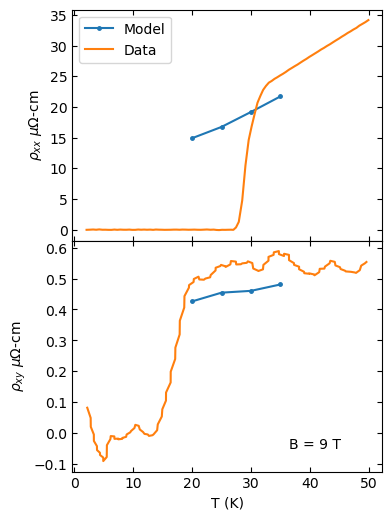

In [10]:
fig,axes = plt.subplots(nrows=2,ncols=1,figsize=(4,6), sharex=True, gridspec_kw={'hspace': 0})

axes[0].plot(temps,rhoxx,marker=".",ms=5,ls="-", label="Model")
axes[0].plot(data_temp_xx[data_temp_xx<50],data_rho_xx[data_temp_xx<50],ls="-", label="Data")
axes[0].set_ylabel(r"$\rho_{xx}$ $\mu\Omega$-cm")
axes[0].legend()

axes[1].plot(temps,rhoxy,marker=".",ms=5,ls="-")
axes[1].plot(data_temp_xy[data_temp_xy<50],data_rho_xy[data_temp_xy<50],ls="-")
axes[1].set_ylabel(r"$\rho_{xy}$ $\mu\Omega$-cm")
axes[1].text(0.7,0.1,"B = 9 T",transform=axes[1].transAxes)
axes[1].set_xlabel("T (K)")

for ax in axes:
    ax.tick_params(direction='in', right=True, top=True)


In [21]:
def create_data(params):

    starttime_global = time()
    thetalist = np.linspace(-14,99,40)

    res_z = 20
    res_xy = 100

    mumultvalue=0.805

    Tzmultvalue,invtau_iso,strength,spread_xy,n = params

    plotScattering=False

    dispersionInstance = dispersion.LSCOdispersion(T= 190e-3,T1multvalue=-0.134,T11multvalue=0.067,Tzmultvalue=Tzmultvalue,mumultvalue=mumultvalue)
    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    starttime = time()
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)
    endtime = time()
    print(f"Time taken to create Fermi Surface = {endtime - starttime}")
    print(f"Doping={FSorbitsInstance.calculateDoping()}")

    def create_rhozz(phi,Bmag,scattering_in=True):
        phi_rad = np.deg2rad(phi)
        conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=invtau_iso,delta_in_k=True)
        starttime = time()
        conductivityInstance.createAmatrix_Bindependent_isotropic()
        conductivityInstance.create_Hfunc(scatteringmodel="pipidelta_exp",strength=strength,spread_xy=spread_xy,n=n)
        conductivityInstance.createAmatrix_Bindependent_fwdscatter_out()
        if scattering_in: conductivityInstance.createAmatrix_Bindependent_fwdscatter_in()
        endtime = time()
        print(f"Time taken to create B independent Amatrix =  {endtime - starttime}")

        def getsigma(theta,Bmag=Bmag):
            B = [Bmag*np.sin(np.deg2rad(theta))*np.cos(phi_rad),Bmag*np.sin(np.deg2rad(theta))*np.sin(phi_rad),Bmag*np.cos(np.deg2rad(theta))]
            conductivityInstance.createAmatrix_Bdependent(B)
            conductivityInstance.createAlpha()
            conductivityInstance.createSigma()

            #print(f"Theta={theta}. Calculated total area: {conductivityInstance.areasum}. Number of orbits used {len(conductivityInstance.FSorbitsInstance.FSorbits)}. Size of Amatrix: {conductivityInstance.n}")
            return conductivityInstance.sigma,conductivityInstance.areasum


        sigmalist,rholist,arealist = makelist_parallel(getsigma,thetalist)
        #sigma_zero,area_zero = getsigma(theta=0,Bmag=0)
        #sigma_9T,area_9T = getsigma(theta=0,Bmag=9)

        #rho_zero = np.linalg.inv(sigma_zero)
        #rho_9T = np.linalg.inv(sigma_9T)

        rhozzlist= [rho[2,2]*10e-5 for rho in rholist]
        #print(f"rho_xx = {rho_zero[0,0]*10e-2}, rho_xy (9 T) = {rho_9T[0,1]*10e-2}")

        endtime_global = time()
        print(f"execution time: {endtime_global-starttime_global}")

        return rhozzlist

    #generate data
    rhozzlist0 = create_rhozz(phi=0,Bmag=45,scattering_in=True)
    rhozzlist45 = create_rhozz(phi=45,Bmag=45,scattering_in=True)

    return rhozzlist0,rhozzlist45,thetalist


In [32]:
data_theta_phi0_30K_22perc,data_phi0_30K_22perc = np.loadtxt(repository_directory+"data/admr_data/2601C/2601C_phi0_T30K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
data_theta_phi45_30K_22perc,data_phi45_30K_22perc = np.loadtxt(repository_directory+"data/admr_data/2601C/2601C_phi45_T30K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

fit_phi0_30K_22perc,fit_phi45_30K_22perc,fit_theta_30K_22perc = create_data((0.03052,7.7,13.5,0.1523052248981892,7.694942153701261))

Time taken to create Fermi Surface = 0.05809426307678223
Doping = 0.22818195871982705%
Doping=0.22818195871982705
Time taken to create B independent Amatrix =  0.4120769500732422
execution time: 4.816789388656616
Time taken to create B independent Amatrix =  0.43712663650512695
execution time: 6.856750965118408


In [41]:
red = "#D95F5F"
dark_red = "#A94444"

blue = "#4C78A8"
dark_blue = "#345578"

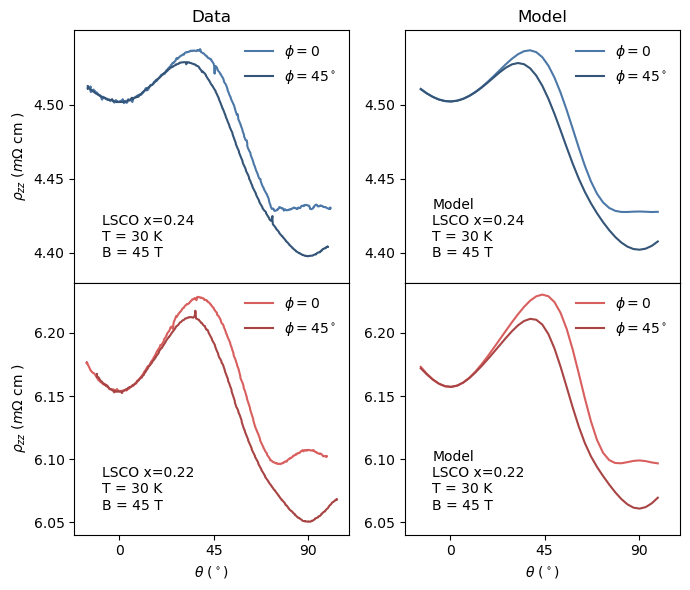

In [60]:
#making panel for magnet time proposal

fig,axes = plt.subplots(nrows=2,ncols=2,figsize=(7,6), sharex=True, gridspec_kw={'hspace': 0})

axes[0,0].plot(data_theta_phi0_30K,data_phi0_30K,color=blue,label=r"$\phi=0$")
axes[0,0].plot(data_theta_phi45_30K,data_phi45_30K,color=dark_blue,label=r"$\phi=45^\circ$")
axes[1,0].plot(data_theta_phi0_30K_22perc,data_phi0_30K_22perc,color=red,label=r"$\phi=0$")
axes[1,0].plot(data_theta_phi45_30K_22perc,data_phi45_30K_22perc,color=dark_red,label=r"$\phi=45^\circ$")

axes[0,1].plot(fit_theta_30K,fit_phi0_30K,color=blue,label=r"$\phi=0$")
axes[0,1].plot(fit_theta_30K,fit_phi45_30K,color=dark_blue,label=r"$\phi=45^\circ$")
axes[1,1].plot(fit_theta_30K_22perc,fit_phi0_30K_22perc,color=red,label=r"$\phi=0$")
axes[1,1].plot(fit_theta_30K_22perc,fit_phi45_30K_22perc,color=dark_red,label=r"$\phi=45^\circ$")

#put xlabels on bottom row
for ax in axes[1,:]:
    ax.set_xlabel(r'$\theta$ ($^\circ$)')
    ax.set_xticks([0, 45, 90])

#put ylabels on left column
for ax in axes[:,0]:
    ax.set_ylabel(r"$\rho_{zz}$ ($m\Omega$ cm )")

#make ylims the same for each row
for ax in axes[0,:]:
    ax.set_ylim(4.38,4.55)
    ax.set_yticks([4.4,4.45,4.5])

for ax in axes[1,:]:
    ax.set_ylim(6.04,6.24)
    ax.set_yticks([6.05,6.1,6.15,6.2])

axes[0,0].text(0.1,0.1,"LSCO x=0.24\nT = 30 K\nB = 45 T",transform=axes[0,0].transAxes)
axes[1,0].text(0.1,0.1,"LSCO x=0.22\nT = 30 K\nB = 45 T",transform=axes[1,0].transAxes)

axes[0,1].text(0.1,0.1,"Model\nLSCO x=0.24\nT = 30 K\nB = 45 T",transform=axes[0,1].transAxes)
axes[1,1].text(0.1,0.1,"Model\nLSCO x=0.22\nT = 30 K\nB = 45 T",transform=axes[1,1].transAxes)

axes[0,0].set_title("Data")
axes[0,1].set_title("Model")

#put legends on all axes
for ax in axes.flatten():
    ax.legend(loc="upper right",fontsize=10,frameon=False)

fig.tight_layout()
fig.savefig("data_for_proposal.png",dpi=300,bbox_inches='tight')



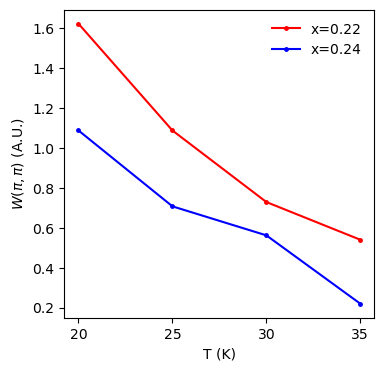

In [61]:
peak_22perc = np.exp([14.3,13.9,13.5,13.2])
peak_24perc = np.exp([13.9,13.47,13.24,12.3])

fig,axes = plt.subplots(nrows=1,ncols=1,figsize=(4,4))

axes.plot(temps,peak_22perc/1e6,marker=".",ms=5,ls="-",label="x=0.22",color='red')
axes.plot(temps,peak_24perc/1e6,marker=".",ms=5,ls="-",label="x=0.24",color='blue')
axes.set_xlabel("T (K)")
axes.set_ylabel(r"$W(\pi,\pi)$ (A.U.)")

axes.set_xticks([20,25,30,35])
axes.legend(loc="upper right",fontsize=10,frameon=False)
fig.savefig("pipiscattering_for_proposal.png",dpi=300,bbox_inches='tight')
